In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

In [2]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]

In [3]:
device = "cuda"

In [4]:
grid = [ # T = 0.000059,  # T = 0.000078
    (0.001, 64),   # T = 0.000039
    (0.005, 64),   # T = 0.000078
    (0.01,  64),   # T = 0.000156
    (0.025,  64),   # T = 0.000312
    (0.05,  64),   # T = 0.000781  # T = 0.012500 (Scorching Hot - might cause loss spikes!)
]

In [5]:
batch_sizes = [16, 32, 64, 128, 256, 528, 1024]
fixed_eta = 0.05
grid = [(fixed_eta, B) for B in batch_sizes]
print(grid)

[(0.05, 16), (0.05, 32), (0.05, 64), (0.05, 128), (0.05, 256), (0.05, 528), (0.05, 1024)]


Universal valley found and anchored. Starting thermodynamic sweep...
--- Running SDE Diffusion (Exploration) Experiment ---

=== Seed 1 ===
  Testing Diffusion at B=16...
    Final distance: 0.440995
  Testing Diffusion at B=32...
    Final distance: 0.340528
  Testing Diffusion at B=64...
    Final distance: 0.324790
  Testing Diffusion at B=128...
    Final distance: 0.322345
  Testing Diffusion at B=256...
    Final distance: 0.321885
  Testing Diffusion at B=512...
    Final distance: 0.321560

=== Seed 2 ===
  Testing Diffusion at B=16...
    Final distance: 0.461208
  Testing Diffusion at B=32...
    Final distance: 0.339930
  Testing Diffusion at B=64...
    Final distance: 0.324650
  Testing Diffusion at B=128...
    Final distance: 0.322444
  Testing Diffusion at B=256...
    Final distance: 0.321862
  Testing Diffusion at B=512...
    Final distance: 0.321546

=== Seed 3 ===
  Testing Diffusion at B=16...
    Final distance: 0.443504
  Testing Diffusion at B=32...
    Final d

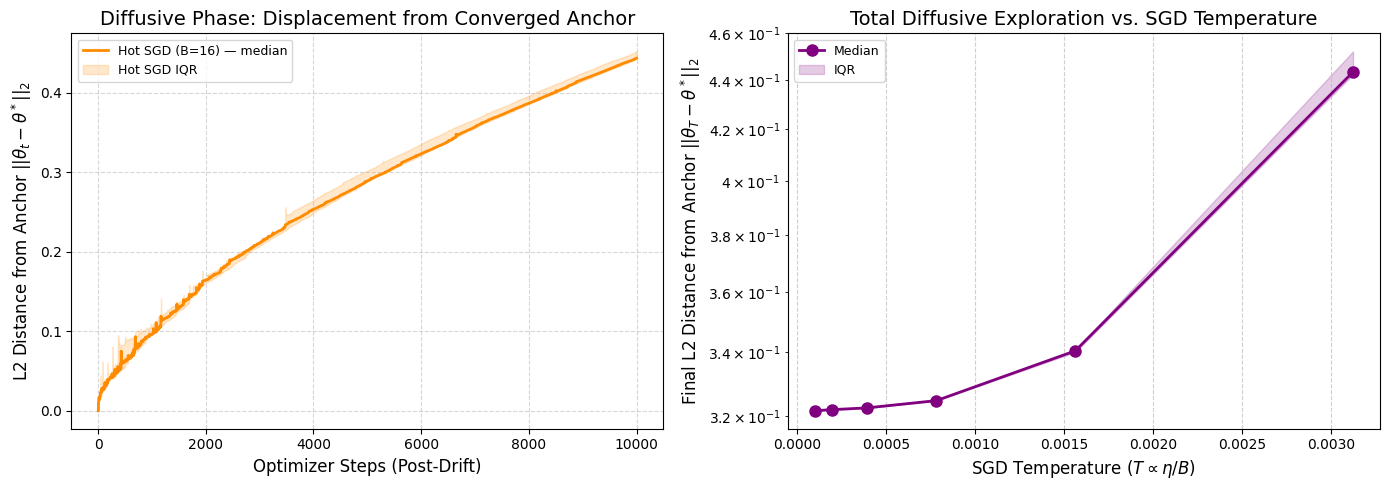

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
seeds = [1, 2, 3, 4, 5]
diffusive_steps = 10000  # optimizer steps for the diffusive (measurement) phase
measure_every   = 5      # record distance every N steps

batch_sizes = [16, 32, 64, 128, 256, 512]
fixed_eta = 0.05
grid = [(fixed_eta, B) for B in batch_sizes]
temperatures = [fixed_eta / B for B in batch_sizes]

# ── Train the baseline model ONCE to find the universal valley ──────────────
torch.manual_seed(42)
baseline_model = FlatMLP(input_dim=dataset.tensors[0].shape[1], hidden_dim=512, num_classes=10).to(device)
baseline_optimizer = torch.optim.SGD(baseline_model.parameters(), lr=fixed_eta)
baseline_loader = DataLoader(dataset, batch_size=128, shuffle=True)
baseline_model.train()
for epoch in range(100):
    for X_b, y_b in baseline_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        baseline_optimizer.zero_grad()
        criterion(baseline_model(X_b), y_b).backward()
        baseline_optimizer.step()

universal_anchor = torch.cat([p.data.contiguous().view(-1)
                               for p in baseline_model.parameters()]).clone()
torch.save(baseline_model.state_dict(), "converged_valley.pt")
print("Universal valley found and anchored. Starting thermodynamic sweep...")

# distance_histories[(eta, B)] → list of 1-D arrays, one per seed
distance_histories = {(eta, B): [] for eta, B in grid}

print("--- Running SDE Diffusion (Exploration) Experiment ---")

for seed in seeds:
    print(f"\n=== Seed {seed} ===")
    for eta, B in grid:
        print(f"  Testing Diffusion at B={B}...")

        model = FlatMLP(input_dim=dataset.tensors[0].shape[1], hidden_dim=512, num_classes=10).to(device)
        model.load_state_dict(torch.load("converged_valley.pt", weights_only=True))
        optimizer = torch.optim.SGD(model.parameters(), lr=eta)

        model.train()
        distance_trajectory = []

        # Each (seed, B) pair gets its own independent generator so that
        # different batch sizes do NOT share the same random data ordering.
        g = torch.Generator()
        g.manual_seed(seed * 100_000 + B)
        data_iter = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=g))

        step = 0
        while step < diffusive_steps:
            try:
                X_b, y_b = next(data_iter)
            except StopIteration:
                data_iter = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=g))
                X_b, y_b = next(data_iter)
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            if step % measure_every == 0:
                current_weights = torch.cat([p.data.contiguous().view(-1) for p in model.parameters()])
                sq_dist = torch.norm(current_weights - universal_anchor, p=2).item() ** 2
                distance_trajectory.append(sq_dist)
            optimizer.step()
            step += 1

        distance_histories[(eta, B)].append(np.array(distance_trajectory))
        print(f"    Final squared distance: {distance_trajectory[-1]:.6f}")

# ── Helper: compute median + IQR across seeds ────────────────────────────────
def seed_stats(arrays):
    min_len = min(len(a) for a in arrays)
    stacked = np.stack([a[:min_len] for a in arrays])   # (n_seeds, T)
    return (np.median(stacked, axis=0),
            np.percentile(stacked, 25, axis=0),
            np.percentile(stacked, 75, axis=0),
            min_len)

print("\nGenerating Plots...")

cold_key = (grid[-1][0], grid[-1][1])
hot_key  = (grid[0][0],  grid[0][1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: trajectory for hot & cold ─────────────────────────────────────────
for key, color, lbl in [(hot_key, 'darkorange', 'Hot SGD')]:
    median, q25, q75, min_len = seed_stats(distance_histories[key])
    x = np.arange(1, min_len + 1) * measure_every
    _, B = key
    ax1.plot(x, median, color=color, linewidth=2, label=f'{lbl} (B={B}) — median')
    ax1.fill_between(x, q25, q75, color=color, alpha=0.2, label=f'{lbl} IQR')

ax1.set_title("Diffusive Phase: Displacement from Converged Anchor", fontsize=14)
ax1.set_xlabel("Optimizer Steps (Post-Drift)", fontsize=12)
ax1.set_ylabel(r"Squared L2 Distance from Anchor $||\theta_t - \theta^*||_2^2$", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# ── Right: final exploration vs temperature ──────────────────────────────────
final_medians, final_q25, final_q75 = [], [], []
for eta, B in grid:
    finals = np.array([arr[-1] for arr in distance_histories[(eta, B)]])
    final_medians.append(np.median(finals))
    final_q25.append(np.percentile(finals, 25))
    final_q75.append(np.percentile(finals, 75))

ax2.plot(temperatures, final_medians,
         marker='o', markersize=8, color='purple', linewidth=2, label='Median')
ax2.fill_between(temperatures, final_q25, final_q75,
                 color='purple', alpha=0.2, label='IQR')
ax2.set_title("Total Diffusive Exploration vs. SGD Temperature", fontsize=14)
ax2.set_xlabel(r"SGD Temperature ($T \propto \eta/B$)", fontsize=12)
ax2.set_ylabel(r"Final Squared L2 Distance from Anchor $||\theta_T - \theta^*||_2^2$", fontsize=12)
ax2.set_yscale('log')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Diffusion_Exploration_DriftSplit.png", dpi=300)
plt.show()


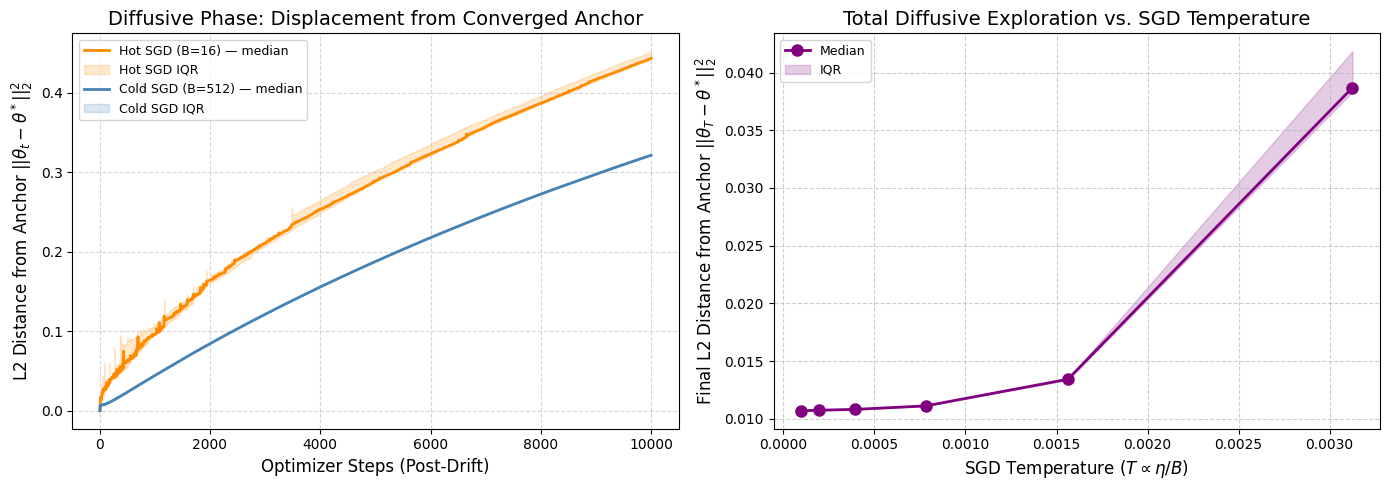

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: trajectory for hot & cold ─────────────────────────────────────────
for key, color, lbl in [(hot_key, 'darkorange', 'Hot SGD'), (cold_key, 'steelblue', 'Cold SGD')]:
    median, q25, q75, min_len = seed_stats(distance_histories[key])
    x = np.arange(1, min_len + 1) * measure_every
    _, B = key
    ax1.plot(x, median, color=color, linewidth=2, label=f'{lbl} (B={B}) — median')
    ax1.fill_between(x, q25, q75, color=color, alpha=0.2, label=f'{lbl} IQR')

ax1.set_title("Diffusive Phase: Displacement from Converged Anchor", fontsize=14)
ax1.set_xlabel("Optimizer Steps (Post-Drift)", fontsize=12)
ax1.set_ylabel(r"L2 Distance from Anchor $||\theta_t - \theta^*||^2_2$", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)


# ── Right: final exploration vs temperature ──────────────────────────────────
final_medians, final_q25, final_q75 = [], [], []
for eta, B in grid:
    finals = np.array([arr[-1] for arr in distance_histories[(eta, B)]])
    final_medians.append(np.median(finals))
    final_q25.append(np.percentile(finals, 25))
    final_q75.append(np.percentile(finals, 75))

ax2.plot(temperatures, final_medians,
         marker='o', markersize=8, color='purple', linewidth=2, label='Median')
ax2.fill_between(temperatures, final_q25, final_q75,
                 color='purple', alpha=0.2, label='IQR')
ax2.set_title("Total Diffusive Exploration vs. SGD Temperature", fontsize=14)
ax2.set_xlabel(r"SGD Temperature ($T \propto \eta/B$)", fontsize=12)
ax2.set_ylabel(r"Final L2 Distance from Anchor $||\theta_T - \theta^*||^2_2$", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Diffusion_Exploration_DriftSplit.png", dpi=300)
plt.show()
